#### Znajdź, opisz i oceń klastry w zbiorze Country-data.csv.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
country=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/Country-data.csv")

In [ ]:
country

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
country=country.drop(['country'], axis=1)
country

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
data=scaler.fit(country).transform(country)
data

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

In [ ]:
from sklearn.cluster import KMeans
wcss_list=[]
for i in range(1,9):
  kmeans_model=KMeans(i,random_state=1)
  kmeans_model.fit(data)
  wcss_list.append(kmeans_model.inertia_)

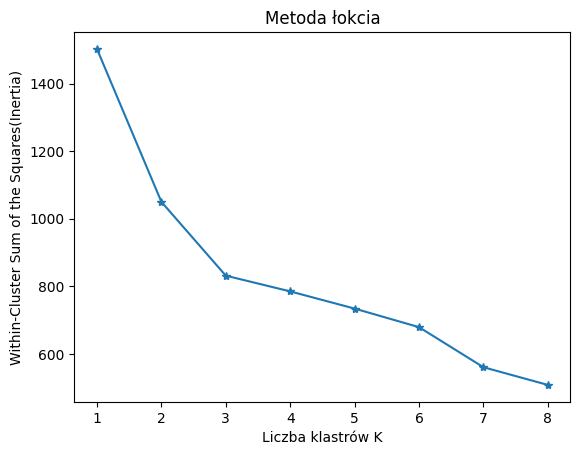

In [ ]:
import matplotlib.pyplot as plt
# Wykres inertia(WCSS) i liczby klastrów
plt.plot(range(1, 9), wcss_list,  marker='*')
plt.title('Metoda łokcia')
plt.xlabel('Liczba klastrów K')
plt.ylabel('Within-Cluster Sum of the Squares(Inertia)')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score_list = []
for i in range(2,10):
  kmeans_model=KMeans(i,random_state=1)
  kmeans_model.fit(data)
  pred=kmeans_model.predict(data)
  score = silhouette_score (data, pred, metric='euclidean')
  score_list.append(score)

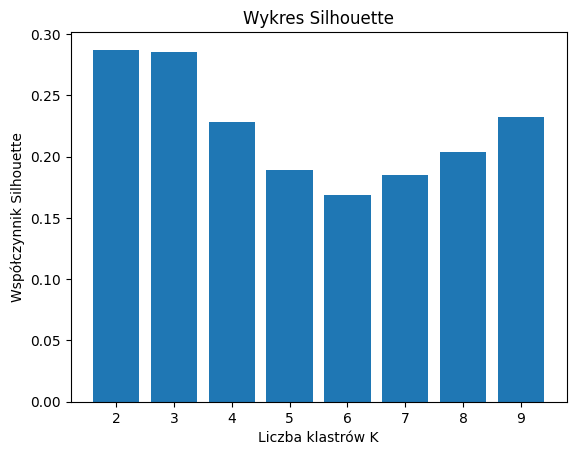

In [ ]:
plt.bar(range(2, 10), score_list)
plt.title('Wykres Silhouette')
plt.xlabel('Liczba klastrów K')
plt.ylabel('Współczynnik Silhouette')
plt.show()

Według metody łokcia lepsza jest liczba klastrów k=3, natomiast według metody Silhouette lepsze jest k=2, ale różnica między wartościami Silhouette dla k=2 i k=3 jest niewielka.

In [ ]:
k = 3
km=KMeans(k,random_state=1)
km.fit(data)
pred=km.predict(data)
pred

array([1, 0, 0, 1, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0,
       0, 2, 0, 1, 1, 0, 1, 2, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 0, 0, 2, 2, 1, 1, 0, 2, 1, 2, 0, 0, 1, 1, 0,
       1, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 0, 1, 1, 2, 0, 1, 0, 0, 1,
       1, 0, 0, 2, 0, 1, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       2, 2, 1, 1, 2, 0, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 2, 2, 2, 0, 1, 2, 2, 0, 0, 1, 0, 2, 2, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1], dtype=int32)

In [ ]:
from sklearn.metrics import silhouette_score
ssc=silhouette_score(data,pred)
print("Indeks Silhouette Score :", ssc)

Indeks Silhouette Score : 0.285600988953231


#### Obserwacje w złej grupie

In [ ]:
from sklearn.metrics import silhouette_samples
silhouette_samples(data,pred)
silhouette_vals=silhouette_samples(data,pred)
country[silhouette_vals<0]

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
11,8.6,69.5,4.97,50.9,41100,7.440,76.0,2.16,20700
42,3.6,50.2,5.97,57.5,33900,2.010,79.9,1.42,30800
43,3.4,66.0,7.88,62.9,28300,-1.430,77.5,1.51,19800
74,4.6,35.0,7.63,32.9,29600,1.770,81.4,3.03,30600
84,78.9,35.4,4.47,49.3,3980,9.200,63.8,3.15,1140
108,56.0,47.8,6.78,60.7,8460,3.560,58.6,3.60,5190
134,7.0,76.3,8.79,77.8,25200,0.485,75.5,1.43,16600
137,53.7,28.6,8.94,27.4,12000,6.350,54.3,2.59,7280
138,4.1,49.4,6.93,46.2,30400,3.160,80.1,1.23,22100


In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
def evaluate_clustering_km(X, k):
  kmeans = KMeans(n_clusters=k, random_state=1).fit(X)
  l = kmeans.labels_

  # --- Silhouette Score ---
  silhouette = silhouette_score(X, l)

  # --- Calinski–Harabasz Index ---
  ch_index = calinski_harabasz_score(X, l)

  #--- Davies–Bouldin Index ---
  dbi=davies_bouldin_score(X, l)

  print(f"\nWynik dla k = {k}")
  print(f"Silhouette Score: {silhouette:.3f}")
  print(f"Calinski–Harabasz Index: {ch_index:.3f}")
  print(f"Davies–Bouldin Index: {dbi:.3f}")

In [ ]:
for k in range(2,4):
  evaluate_clustering_km(data,k)


Wynik dla k = 2
Silhouette Score: 0.287
Calinski–Harabasz Index: 71.137
Davies–Bouldin Index: 1.304

Wynik dla k = 3
Silhouette Score: 0.286
Calinski–Harabasz Index: 66.215
Davies–Bouldin Index: 1.274


In [ ]:
km.cluster_centers_
country['clust']=pred
print('Podsumowanie klastrów:')
summary = country.groupby(['clust']).mean()
summary['count'] = country['clust'].value_counts()
summary = summary.sort_values(by='count', ascending=False)
summary

Podsumowanie klastrów:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,count
clust,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,86
1,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,45
2,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,36


* Klaster 2 (36 krajów)

Najbogatsza i najbardziej stabilna grupa. Charakteryzuje się najwyższymi wskaźnikami dochodu ($\sim 45 \text{k}$) i PKB ($\sim 42 \text{k}$), najniższą śmiertelnością dzieci (5.00), najwyższą oczekiwaną długością życia ($\sim 80$ lat) i najniższą dzietnością (1.75).

*  Klaster 0 (86 krajów)

Największa grupa. Osiąga średnie wyniki dla większości wskaźników. Dochód i PKB są znacząco wyższe niż w Klastrze 1, ale wciąż dalekie od Klastra 2. To kraje, które aktywnie się rozwijają.

*  Klaster 1 (45 krajów)

Najbiedniejsza i najbardziej niestabilna grupa. Charakteryzuje się ekstremalnie niskim dochodem ($\sim 3.5 \text{k}$) i PKB ($\sim 1.7 \text{k}$), najwyższą śmiertelnością dzieci (95.11) oraz najwyższą dzietnością (5.07). W dużej mierze są to kraje Afryki Subsaharyjskiej.

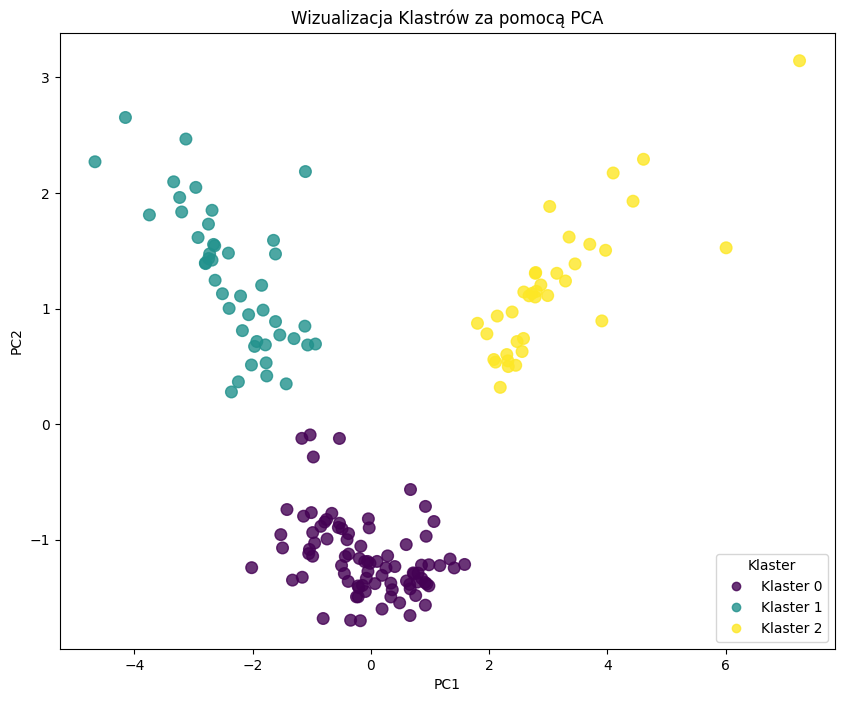

In [ ]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
data_scaled = scaler.fit_transform(country)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_scaled)

pca_df = pd.DataFrame(data = principal_components,
                      columns = ['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = pred

unique_clusters = sorted(pca_df['Cluster'].unique())
labels = [f'Klaster {c}' for c in unique_clusters]

explained_variance = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df['Principal Component 1'],
                      pca_df['Principal Component 2'],
                      c=pca_df['Cluster'],
                      cmap='viridis',
                      s=70,
                      alpha=0.8)

plt.xlabel(f'PC1')
plt.ylabel(f'PC2')
plt.title('Wizualizacja Klastrów za pomocą PCA')

plt.legend(handles=scatter.legend_elements()[0],
           labels=labels,
           title="Klaster",
           loc="lower right")

plt.show()

Na wykresie widać wyraźne grupy, więc separacja wygląda na dobrą, a pojedyncze punkty oddalone od głównych chmur można uznać za kandydatów na obserwacje odstające.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = lof.fit_predict(data)

outliers = np.where(labels == -1)[0]

print("Liczba potencjalnych odstających:", len(outliers))


Liczba potencjalnych odstających: 9


Inercja (WCSS – Within-Cluster Sum of Squares): Suma kwadratów odległości obserwacji od ich centroidów. Podstawa Metody Łokcia.

Ocena: Im niższa inercja, tym lepsze klastrowanie (bardziej zwarte klastry).

Indeks Calinski-Harabasz: Stosunek wariancji między klastrami do wariancji wewnątrz klastrów.

Ocena: Im wyższy wskaźnik, tym lepsza separacja klastrów.

Indeks Daviesa-Bouldina (DBI): Średnia miara podobieństwa między klastrami. Opiera się na stosunku odległości wewnątrz klastra do odległości między centroidami.

Ocena: Im niższy wskaźnik, tym lepsza separacja i tym lepszy model.